In [6]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
pdfs = list(Path("./raw/").glob("*.pdf"))

In [8]:
import ollama
import fitz

In [12]:
OLLAMA_URL = "http://localhost:11434"
TEXT_EMBED_MODEL = "nomic-embed-text"
LLM_MODEL = "llama3.2-vision"

In [9]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_ollama import OllamaEmbeddings
import concurrent
from langchain_community.document_loaders import PyPDFLoader

In [ ]:
text_splitter = SemanticChunker(
    embeddings, 
    breakpoint_threshold_type="percentile" 
)

In [ ]:
embeddings = OllamaEmbeddings(
    model="qwen3-embedding",
    base_url="http://localhost:11434"
)

In [10]:
from tqdm.auto import tqdm

In [ ]:
def semantic_chunking():
    embeddings = OllamaEmbeddings(
    model="qwen3-embedding",
    base_url="http://localhost:11434"
    )

    text_splitter = SemanticChunker(
    embeddings, 
    breakpoint_threshold_type="percentile" 
    )
    docs = []
    for doc in pdfs:
        loader = PyPDFLoader(doc)

        docs.extend(loader.load())
        
    semantic_chunks = []
    for doc1 in tqdm(docs, desc="Splitting documents"):
        semantic_chunks.extend(text_splitter.split_documents([doc1]))

    return semantic_chunks

semantic_chunking()

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
import concurrent.futures


In [ ]:

def load_single_pdf(pdf_path):

    loader = PyPDFLoader(pdf_path)
    return loader.load()

def chunk_single_doc(doc, text_splitter):
    return text_splitter.split_documents([doc])

def semantic_chunking(pdfs):
    embeddings = OllamaEmbeddings(
        model="mxbai-embed-large",
        base_url="http://localhost:11434"
    )

    text_splitter = SemanticChunker(
        embeddings, 
        breakpoint_threshold_type="percentile" 
    )
    pre_splitter = RecursiveCharacterTextSplitter(
        chunk_size=1500,   # characters, not tokens
        chunk_overlap=200
    )
    docs = []
    # 1. Parallelize PDF Loading
    # ThreadPool is great here because file I/O releases the GIL.
    print("Starting parallel PDF loading...")
    with concurrent.futures.ThreadPoolExecutor() as executor:
        # Map applies the function to the iterable concurrently
        results = list(tqdm(executor.map(load_single_pdf, pdfs), total=len(pdfs), desc="Loading PDFs"))
        for res in results:
            docs.extend(res)
    
    docs = pre_splitter.split_documents(docs)
        
    semantic_chunks = []
    
    MAX_WORKERS = 20
    
    print(f"Starting parallel chunking with {MAX_WORKERS} workers...")
    with concurrent.futures.ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        # Submit tasks to the executor
        futures = [executor.submit(chunk_single_doc, doc, text_splitter) for doc in docs]
        
        # as_completed yields futures as they finish, keeping the progress bar accurate
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(docs), desc="Splitting documents"):
            try:
                semantic_chunks.extend(future.result())
            except Exception as e:
                print(f"Skipping a chunk due to error: {e}")  # Don't crash on one bad doc

    final_chunks = []

    for chunk in semantic_chunks:
        if len(chunk.page_content) > 1800:
            final_chunks.extend(pre_splitter.split_documents([chunk]))
        else:
            final_chunks.append(chunk)
    
    return final_chunks

semantic_chunks_parallel = semantic_chunking(pdfs)

Starting parallel PDF loading...


Loading PDFs:   0%|          | 0/18 [00:00<?, ?it/s]

Starting parallel chunking with 20 workers...


Splitting documents:   0%|          | 0/656 [00:00<?, ?it/s]

In [14]:
import chromadb
from chromadb.utils.embedding_functions import OllamaEmbeddingFunction


In [15]:
client = chromadb.PersistentClient(path="chroma_db")

ef = OllamaEmbeddingFunction(
    model_name = "mxbai-embed-large",
    url="http://localhost:11434/api/embeddings"
)

In [16]:
collection = client.get_or_create_collection(name="semantic_texts", embedding_function=ef)

In [17]:
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from ollama import ResponseError

embeddings_model = OllamaEmbeddings(model="mxbai-embed-large", base_url="http://localhost:11434")

# Re-split any oversized chunks (more aggressive threshold)
safety_splitter = RecursiveCharacterTextSplitter(chunk_size=1200, chunk_overlap=100)
final_chunks = []
for chunk in semantic_chunks_parallel:
    if len(chunk.page_content) > 1200:
        final_chunks.extend(safety_splitter.split_documents([chunk]))
    else:
        final_chunks.append(chunk)

print(f"Before: {len(semantic_chunks_parallel)}, After: {len(final_chunks)}")

texts = [doc.page_content for doc in final_chunks]
metadatas = [doc.metadata for doc in final_chunks]

# Embed one-by-one to avoid any batch issues
all_embeddings = []
for i in tqdm(range(len(texts)), desc="Embedding"):
    try:
        emb = embeddings_model.embed_documents([texts[i]])
        all_embeddings.extend(emb)
    except ResponseError:
        print(f"Chunk {i} too long ({len(texts[i])} chars), sub-splitting...")
        sub = safety_splitter.split_text(texts[i])
        # Just embed the first sub-chunk to keep 1:1 mapping
        all_embeddings.extend(embeddings_model.embed_documents([sub[0]]))

assert len(all_embeddings) == len(texts), "Mismatch!"

collection.add(
    ids=[f"chunk_{i}" for i in range(len(texts))],
    documents=texts,
    metadatas=metadatas,
    embeddings=all_embeddings
)


Before: 1481, After: 1693


Embedding:   0%|          | 0/1693 [00:00<?, ?it/s]

Embedding: 100%|██████████| 1693/1693 [07:22<00:00,  3.82it/s]


In [31]:
r = collection.get(include=['embeddings',"documents","metadatas"])

In [18]:
from rank_bm25 import BM25Okapi
import pickle

In [19]:
tokenized_corpus = [doc.lower().split(" ") for doc in texts]

In [57]:
len(texts)

1693

In [20]:
bm25 = BM25Okapi(tokenized_corpus)

In [21]:
with open("bm25_index.pkl", "wb") as f:
    pickle.dump(bm25, f)


In [22]:
query = "pvp coatings"
tokenized_query = query.lower().split(" ")

In [64]:
scores = bm25.get_scores(tokenized_query)

In [66]:
texts[1667]

'Johansson and X. Zhang, Metal\nnanowire networks: Recent advances and challenges for new\ngeneration photovoltaics,Materi. Today Energy, 2019,13, 152–185. 12 K. Chen, B. Zhao, L. Wu, T. Hu, Y. Xiang and T. Chen, et al.,\nSilver nanowire networks on textured silicon as low-\nemissivity coatings for photovoltaic/thermal applications,\nSol. Energy, 2024, 267, 112253. 13 H. Lu, J. Lin, N. Wu, S. Nie, Q. Luo and C.'

In [52]:
import numpy as np

Top 10 results for query: '['pvp', 'coatings']'

Rank 1 | Chunk Index 1667 | Score: 7.92
Preview: Johansson and X. Zhang, Metal
nanowire networks: Recent advances and challenges for new
generation p...



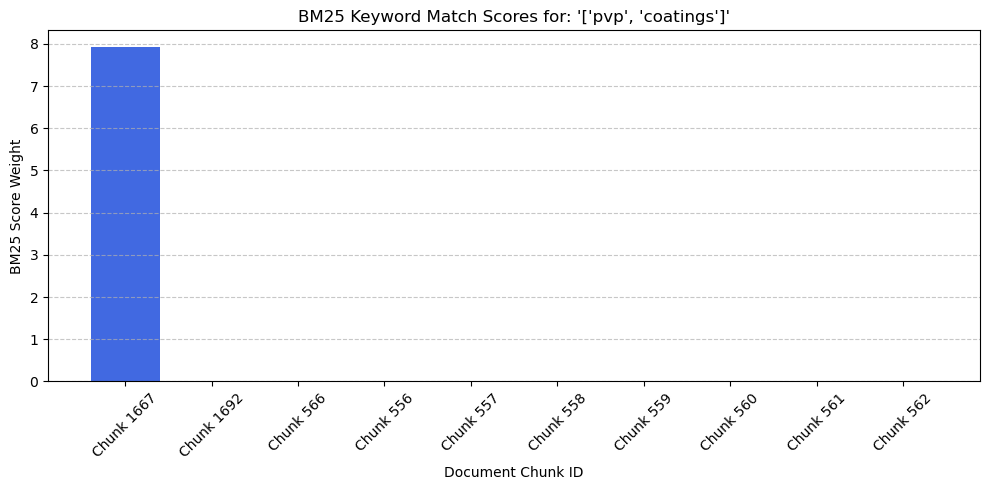

In [65]:

# 3. Find the top 10 highest scoring slices using numpy
top_k = 10
# np.argsort sorts smallest to largest, so [::-1] reverses it to Largest -> Smallest
top_indices = np.argsort(scores)[::-1][:top_k]
top_scores = scores[top_indices]
# 4. Print out the text snippets so you can see what it actually matched
print(f"Top {top_k} results for query: '{tokenized_query}'\n")
for i, idx in enumerate(top_indices):
    score = scores[idx]
    if score > 0:  # Only show it if it actually found a match!
        print(f"Rank {i+1} | Chunk Index {idx} | Score: {score:.2f}")
        # Print the first 100 characters of the matching text chunk
        print(f"Preview: {texts[idx][:100]}...\n")
# 5. Visualize the scores as a Bar Chart!
plt.figure(figsize=(10, 5))
plt.bar([f"Chunk {idx}" for idx in top_indices], top_scores, color='royalblue')
plt.title(f"BM25 Keyword Match Scores for: '{tokenized_query}'")
plt.xlabel("Document Chunk ID")
plt.ylabel("BM25 Score Weight")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()